# Proyecto MDS7205 - Grafo de Conocimiento sobre PokeAPI

**Iniciativa de Datos e IA - Universidad de Chile**

Este reporte tecnico documenta el diseño, implementacion, consulta y analisis de un
grafo de conocimiento construido sobre **PokeAPI** (el esquema relacional completo de
Pokemon, 177 tablas CSV) modelado como **grafo de propiedades** y cargado en **Neo4j**.

## Motivacion

Queremos entender la estructura del universo Pokemon como red: como se ramifican las
evoluciones, como la crianza conecta especies, y si el balance de tipos esconde ciclos de
ventaja en vez de un tipo dominante. PokeAPI deja atacar eso como grafo, y de paso cumple el
criterio del enunciado (ser una red *interesante*) en tres frentes que verificamos sobre los
datos:

1. **Ciclos**: la efectividad de tipos es un grafo dirigido con ciclos reales
   (p.ej. `fighting -> ice -> flying -> fighting`) y self-loops (`ghost`, `dragon`).
2. **Recursion**: la evolucion es una jerarquia recursiva via la self-FK
   `evolves_from_species_id`.
3. **N-a-N navegable**: la compatibilidad de crianza por *egg groups* forma un grafo
   masivo con un componente conexo gigante.

El grafo final tiene del orden de **130 mil nodos** y **900 mil aristas**, dominadas por
la relacion `CAN_LEARN` (que movimientos puede aprender cada Pokemon), que ademas es un
**multigrafo con propiedades en la arista** (el caso canonico donde un grafo de
propiedades supera a RDF puro).


## Preguntas de investigacion

Antes de implementar definimos que queriamos averiguar de la red. Estas son las preguntas y la
capacidad de grafo que cada una explota; las consultas P1-P9 (seccion 3) y los dos modelos
(seccion 4) las responden.

1. **P1** Existen ciclos de super-efectividad entre tipos, o hay un tipo que le gana a todos? (ciclos dirigidos)
2. **P2** Cuales son los linajes evolutivos completos y cual es el mas largo? (paths recursivos)
3. **P3** Bajo que condiciones evoluciona Eevee a cada una de sus formas? (relacion n-aria reificada)
4. **P4** En que comunidades naturales agrupa la crianza por egg groups? (deteccion de comunidades)
5. **P5** Que especies actuan como puente entre esas comunidades de crianza? (betweenness)
6. **P6** Que tipo es ofensivamente mas central, propagando ventaja por toda la cadena? (PageRank ponderado)
7. **P7** Que par de Pokemon comparte mas movimientos aprendibles? (proyeccion N-a-N del multigrafo)
8. **P8** Que areas concentran mas biodiversidad de especies? (agregacion sobre encuentros reificados)
9. **P9** En que linaje se gana mas poder de la forma base a la final? (recursion + agregacion sobre el path)

Y dos preguntas para el ML basico:

- **ML-1** El fenotipo de un Pokemon (stats y repertorio de movimientos) basta para predecir su tipo, o el tipo es una etiqueta de diseño sin señal fenotipica?
- **ML-2** Se puede predecir si dos especies pueden criar mirando solo su fenotipo, sin conocer el egg group? Y cuanto de esa prediccion es nada mas la estructura del grafo?


## Setup

Conexion al Neo4j levantado por `pipeline/load_all.sh` (puerto bolt 7687, sin auth).


In [1]:
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
%matplotlib inline

driver = GraphDatabase.driver("bolt://localhost:7687", auth=None)
def q(query):
    """Ejecuta Cypher y devuelve un DataFrame."""
    with driver.session() as s:
        return pd.DataFrame([r.data() for r in s.run(query)])
print("conectado:", q("RETURN 'Neo4j ' + toString(1) AS ok").iloc[0,0])

conectado: Neo4j 1


## 1. Modelo del grafo

El esquema relacional snowflake de PokeAPI se mapea a un grafo de propiedades: cada
tabla-entidad es un *label*, cada FK una relacion, y las tablas-puente con columnas
extra se vuelven **relaciones con propiedades** (`CAN_LEARN` carga nivel/metodo/version;
`HAS_TYPE` carga el slot; etc). Los encuentros se **reifican** como nodos `Encounter`
(relacion n-aria) y los nombres multilingues (11 idiomas) como nodos `Name`.

El pipeline de carga completo esta en `pipeline/` (`01_constraints` -> `05_scale`).


In [2]:
nodos = q("MATCH (n) UNWIND labels(n) AS l RETURN l AS label, count(*) AS nodos ORDER BY nodos DESC")
display(nodos)
print("TOTAL nodos:", f"{nodos['nodos'].sum():,}")

,label,nodos
0,Encounter,69427
1,Name,51988
2,Item,2176
3,PokemonForm,1578
4,Pokemon,1350
5,LocationArea,1246
6,Location,1096
7,Species,1025
8,Move,937
9,EvolutionCondition,546


TOTAL nodos: 131,880


In [3]:
aristas = q("MATCH ()-[r]->() RETURN type(r) AS relacion, count(*) AS aristas ORDER BY aristas DESC")
display(aristas)
print("TOTAL aristas:", f"{aristas['aristas'].sum():,}")

,relacion,aristas
0,CAN_LEARN,618511
1,COMPATIBLE,71232
2,HAS_ENCOUNTER,69427
3,AT_AREA,69427
4,HAS_NAME,51988
5,HAS_STAT,8100
6,HAS_ABILITY,2928
7,TEAMMATE_OF,2796
8,RUNS_MOVE,2344
9,HAS_TYPE,2115


TOTAL aristas: 908,866


## 2. Caracterizacion del grafo (EDA)

### 2.1 Distribucion del tamaño de movepool
Cuantos movimientos distintos puede aprender cada Pokemon (formas default).


count    1025.0
mean       76.6
std        26.4
min         1.0
25%        61.0
50%        77.0
75%        92.0
max       375.0


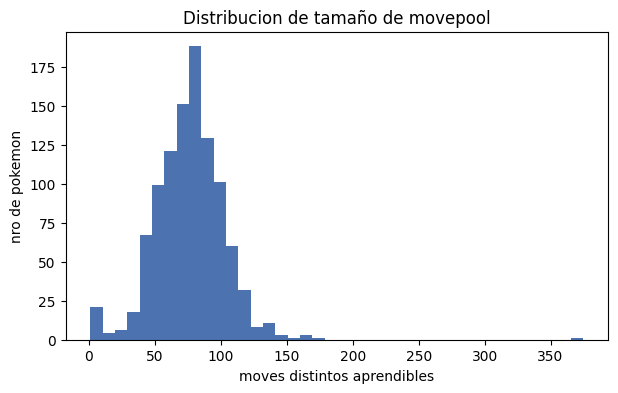

In [4]:
deg = q("""
MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)
RETURN p.identifier AS pokemon, count(DISTINCT m) AS moves
""")
print(deg["moves"].describe().round(1).to_string())
plt.figure(figsize=(7,4))
plt.hist(deg["moves"], bins=40, color="#4c72b0")
plt.xlabel("moves distintos aprendibles"); plt.ylabel("nro de pokemon")
plt.title("Distribucion de tamaño de movepool"); plt.show()

### 2.2 Grafo de crianza (COMPATIBLE)
Dos especies son compatibles si comparten un *egg group* (excluyendo ditto y no-eggs).
Lo analizamos con networkx.


nodos: 873 | aristas: 71,232
componentes: 1 | mayor: 873 | densidad: 0.1871


grado medio: 163.2 | clustering medio: 0.883


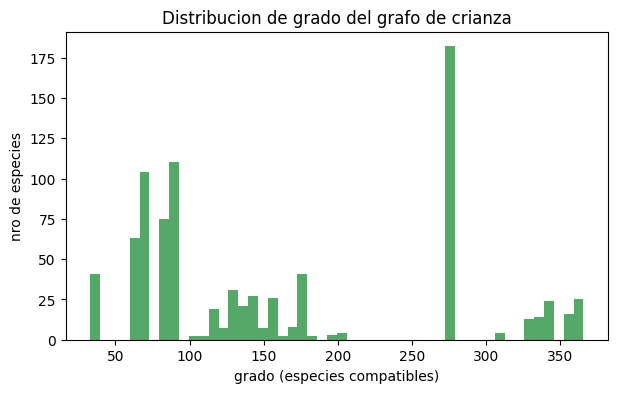

In [5]:
ed = q("MATCH (a:Species)-[:COMPATIBLE]->(b:Species) RETURN a.id AS a, b.id AS b")
G = nx.from_pandas_edgelist(ed, "a", "b")
comps = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"nodos: {G.number_of_nodes():,} | aristas: {G.number_of_edges():,}")
print(f"componentes: {len(comps)} | mayor: {len(comps[0])} | densidad: {nx.density(G):.4f}")
print(f"grado medio: {2*G.number_of_edges()/G.number_of_nodes():.1f} | clustering medio: {nx.average_clustering(G):.3f}")
plt.figure(figsize=(7,4))
plt.hist(list(dict(G.degree()).values()), bins=50, color="#55a868")
plt.xlabel("grado (especies compatibles)"); plt.ylabel("nro de especies")
plt.title("Distribucion de grado del grafo de crianza"); plt.show()

### 2.3 Distribucion de tipos primarios

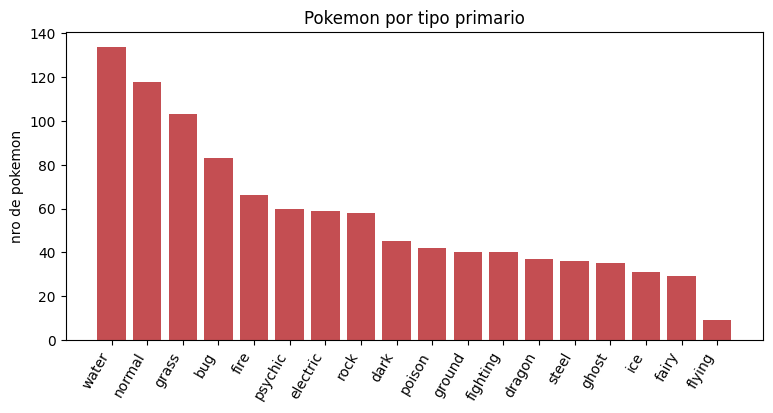

tipo,water,normal,grass,bug,fire,psychic,electric,rock,dark,poison,ground,fighting,dragon,steel,ghost,ice,fairy,flying
n,134,118,103,83,66,60,59,58,45,42,40,40,37,36,35,31,29,9


In [6]:
tipos = q("""
MATCH (p:Pokemon {is_default:true})-[r:HAS_TYPE {slot:1}]->(t:Type)
RETURN t.identifier AS tipo, count(*) AS n ORDER BY n DESC
""")
plt.figure(figsize=(9,4))
plt.bar(tipos["tipo"], tipos["n"], color="#c44e52")
plt.xticks(rotation=60, ha="right"); plt.ylabel("nro de pokemon")
plt.title("Pokemon por tipo primario"); plt.show()
display(tipos.set_index("tipo").T)

### 2.4 Combinaciones de tipo (primario x secundario)
La mitad de los Pokemon son de doble tipo. El mapa cruza el tipo del slot 1 contra el del slot 2
(`(mono)` = sin segundo tipo) y deja ver que combinaciones existen y cuales se repiten.


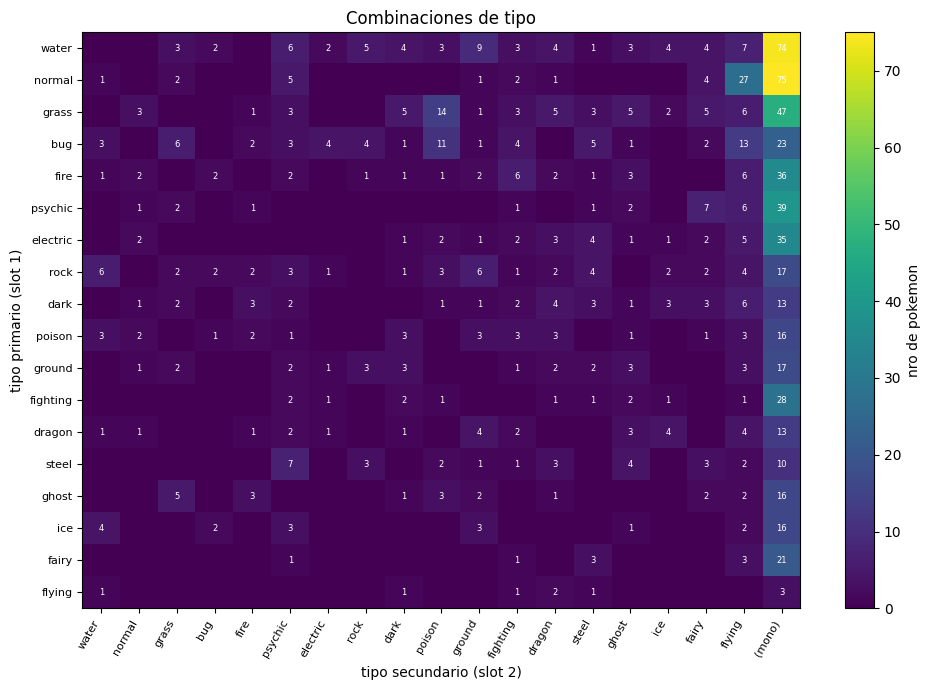

monotipo: 499 | doble tipo: 526


In [7]:
tc = q("""MATCH (p:Pokemon {is_default:true})-[h:HAS_TYPE]->(t:Type)
RETURN p.id AS id, h.slot AS slot, t.identifier AS tipo""")
piv = tc.pivot_table(index="id", columns="slot", values="tipo", aggfunc="first")
piv.columns = ["t1", "t2"]; piv["t2"] = piv["t2"].fillna("(mono)")
orden = tipos["tipo"].tolist(); cols = orden + ["(mono)"]
cross = pd.crosstab(piv["t1"], piv["t2"]).reindex(index=orden, columns=cols, fill_value=0)
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(cross.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden, fontsize=8)
ax.set_xlabel("tipo secundario (slot 2)"); ax.set_ylabel("tipo primario (slot 1)")
for i in range(len(orden)):
    for j in range(len(cols)):
        v = cross.values[i, j]
        if v > 0: ax.text(j, i, int(v), ha="center", va="center", color="white", fontsize=6)
fig.colorbar(im, label="nro de pokemon"); ax.set_title("Combinaciones de tipo")
plt.tight_layout(); plt.show()
print(f"monotipo: {(piv['t2']=='(mono)').sum()} | doble tipo: {(piv['t2']!='(mono)').sum()}")

### 2.5 Cuadro de efectividad de tipos
El grafo dirigido `EFFECTIVENESS` completo (atacante hacia defensor). Rojo es super-efectivo (x2),
verde resistido (x0.5), verde oscuro inmunidad (x0). Es el cuadro sobre el que P1 busca ciclos y P6
mide centralidad ofensiva, asi que conviene tenerlo a la vista.


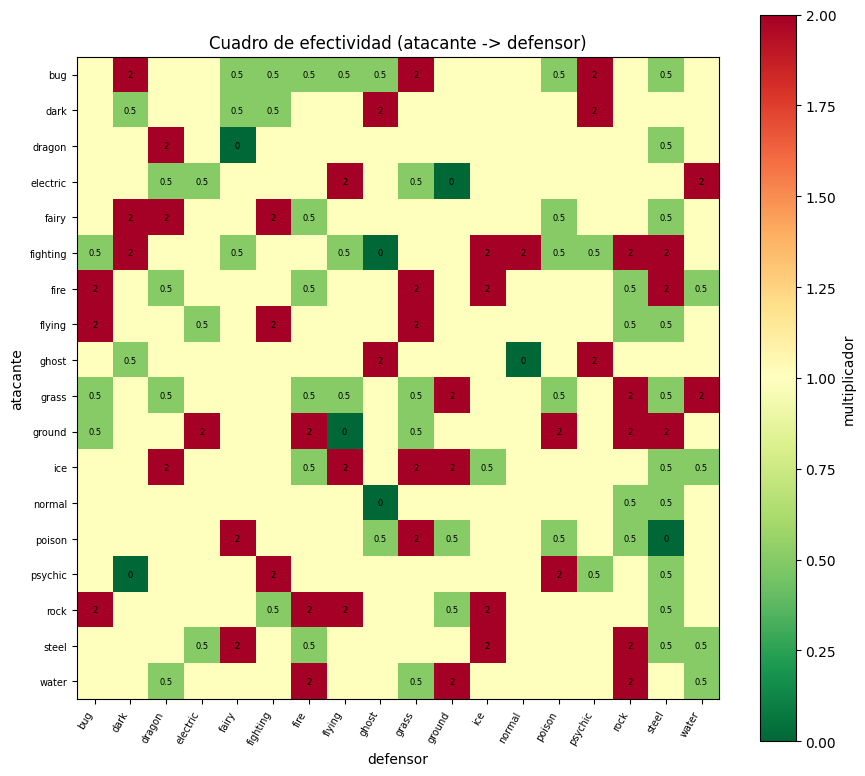

super-efectivo x2: 51 | resistido x0.5: 61 | inmunidad x0: 8


In [8]:
e = q("""MATCH (a:Type)-[r:EFFECTIVENESS]->(b:Type)
RETURN a.identifier AS atk, b.identifier AS def, r.factor AS f""")
tt = sorted(set(e["atk"]) | set(e["def"]))
M = pd.DataFrame(100.0, index=tt, columns=tt)
for _, row in e.iterrows(): M.loc[row["atk"], row["def"]] = row["f"]
M = M / 100.0
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(M.values, cmap="RdYlGn_r", vmin=0, vmax=2)
ax.set_xticks(range(len(tt))); ax.set_xticklabels(tt, rotation=60, ha="right", fontsize=7)
ax.set_yticks(range(len(tt))); ax.set_yticklabels(tt, fontsize=7)
ax.set_xlabel("defensor"); ax.set_ylabel("atacante")
for i in range(len(tt)):
    for j in range(len(tt)):
        v = M.values[i, j]
        if v != 1.0: ax.text(j, i, ("0" if v == 0 else f"{v:g}"), ha="center", va="center", fontsize=6)
fig.colorbar(im, label="multiplicador"); ax.set_title("Cuadro de efectividad (atacante -> defensor)")
plt.tight_layout(); plt.show()
print(f"super-efectivo x2: {int((M.values==2).sum())} | resistido x0.5: {int((M.values==0.5).sum())} | inmunidad x0: {int((M.values==0).sum())}")

### 2.6 Capa multilingue
Cada entidad tiene nombres en 11 idiomas como nodos `Name`. Ejemplo: Pikachu.


In [9]:
q("""
MATCH (s:Species {identifier:'pikachu'})-[:HAS_NAME]->(n:Name)
RETURN n.lang AS lang_id, n.text AS nombre ORDER BY n.lang
""")

,lang_id,nombre
0,1,ピカチュウ
1,2,Pikachu
2,3,피카츄
3,4,皮卡丘
4,5,Pikachu
5,6,Pikachu
6,7,Pikachu
7,8,Pikachu
8,9,Pikachu
9,11,ピカチュウ


## 3. Las consultas que responden P1-P9

Cada consulta plantea su pregunta y la responde con una capacidad de grafo que un `SELECT/JOIN`
no resuelve limpio. Despues de cada resultado va una lectura corta.

### P1 - ¿La super-efectividad de tipos forma ciclos, o hay un tipo invencible?
Ciclos dirigidos de largo 3 en el subgrafo de super-efectividad.

In [10]:
q("""
MATCH path = (t:Type)-[:SUPER_EFFECTIVE*3]->(t)
RETURN [n IN nodes(path) | n.identifier] AS ciclo LIMIT 10
""")

,ciclo
0,"[fighting, steel, fairy, fighting]"
1,"[fighting, dark, psychic, fighting]"
2,"[fighting, ice, flying, fighting]"
3,"[fighting, rock, flying, fighting]"
4,"[flying, grass, rock, flying]"
5,"[flying, fighting, ice, flying]"
6,"[flying, fighting, rock, flying]"
7,"[poison, grass, ground, poison]"
8,"[ground, electric, water, ground]"
9,"[ground, steel, ice, ground]"


La super-efectividad no es un orden lineal: aparecen varias triadas ciclicas
(`fighting -> steel -> fairy -> fighting` y otras), asi que ningun tipo le gana a todos.
Ademas `ghost` y `dragon` salen como self-loops, fuertes contra si mismos.

Visto como grafo dirigido se nota que no hay un tipo sumidero: en rojo va el ciclo
`fighting -> steel -> fairy -> fighting`. El tamaño y color del nodo es su PageRank (la consulta P6),
o sea cuan lejos propaga su ventaja ofensiva por la cadena.

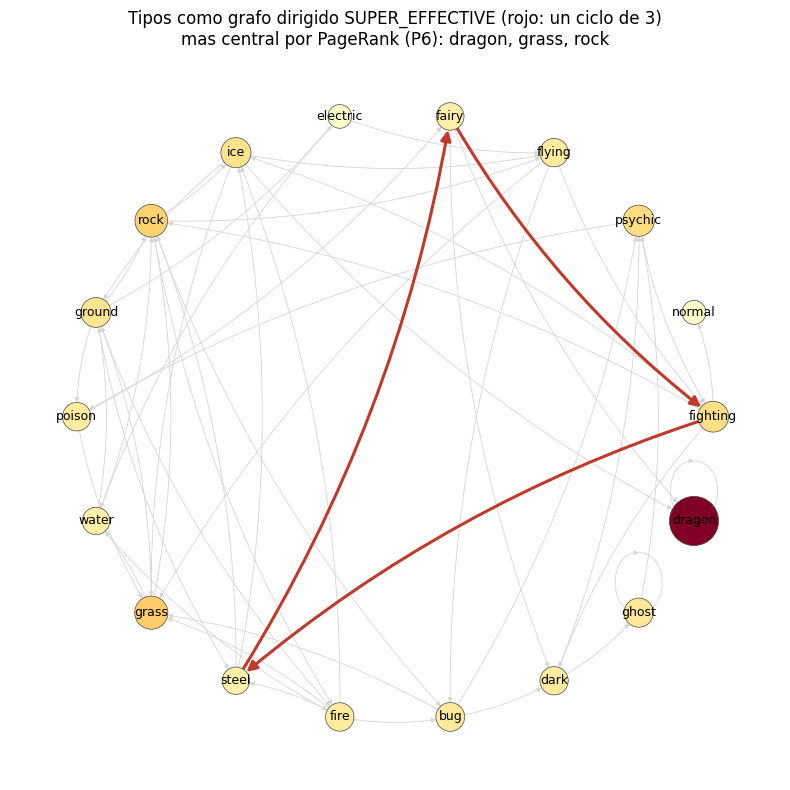

In [11]:
ge = q("MATCH (a:Type)-[:SUPER_EFFECTIVE]->(b:Type) RETURN a.identifier AS s, b.identifier AS t")
G = nx.from_pandas_edgelist(ge, "s", "t", create_using=nx.DiGraph)
pr = nx.pagerank(G); posg = nx.circular_layout(G)
ciclo = [("fighting","steel"),("steel","fairy"),("fairy","fighting")]
plt.figure(figsize=(8,8))
ns = [200 + 5000*pr[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, posg, node_size=ns, node_color=[pr[n] for n in G.nodes()], cmap="YlOrRd", edgecolors="#444", linewidths=0.5)
nx.draw_networkx_edges(G, posg, edgelist=[e for e in G.edges() if e not in ciclo], edge_color="#d5d5d5", arrowsize=7, width=0.6, connectionstyle="arc3,rad=0.1", node_size=ns)
nx.draw_networkx_edges(G, posg, edgelist=ciclo, edge_color="#c0392b", arrowsize=15, width=2.2, connectionstyle="arc3,rad=0.1", node_size=ns)
nx.draw_networkx_labels(G, posg, font_size=9)
top3 = sorted(pr, key=pr.get, reverse=True)[:3]
plt.title("Tipos como grafo dirigido SUPER_EFFECTIVE (rojo: un ciclo de 3)\nmas central por PageRank (P6): " + ", ".join(top3))
plt.axis("off"); plt.tight_layout(); plt.show()

### P2 - ¿Cuales son los linajes evolutivos completos y cual es el mas largo?
Path variable de la raiz a la hoja sobre EVOLVES_TO.

In [12]:
q("""
MATCH p = (raiz:Species)-[:EVOLVES_TO*]->(hoja:Species)
WHERE NOT (:Species)-[:EVOLVES_TO]->(raiz) AND NOT (hoja)-[:EVOLVES_TO]->(:Species)
RETURN [n IN nodes(p) | n.identifier] AS linaje, length(p) AS saltos
ORDER BY saltos DESC, linaje LIMIT 10
""")

,linaje,saltos
0,"[abra, kadabra, alakazam]",2
1,"[applin, dipplin, hydrapple]",2
2,"[aron, lairon, aggron]",2
3,"[axew, fraxure, haxorus]",2
4,"[azurill, marill, azumarill]",2
5,"[bagon, shelgon, salamence]",2
6,"[beldum, metang, metagross]",2
7,"[bellsprout, weepinbell, victreebel]",2
8,"[blipbug, dottler, orbeetle]",2
9,"[bounsweet, steenee, tsareena]",2


Los linajes mas largos tienen 3 especies, o sea 2 saltos, como `bulbasaur -> ivysaur ->
venusaur`. La evolucion es recursiva pero poco profunda: ninguna cadena pasa de 2 pasos.

### P3 - ¿Bajo que condiciones evoluciona Eevee a cada una de sus formas?
Cada fila de evolucion es un nodo `EvolutionCondition`. Leafeon y Glaceon traen varias
(piedra evolutiva o cercania a una roca), por eso se colectan todas.

In [13]:
q("""
MATCH (eevee:Species {identifier:'eevee'})-[:EVOLVES_TO]->(evo:Species)-[:EVOLVES_VIA]->(c:EvolutionCondition)
RETURN evo.identifier AS evolucion,
       collect({trigger:c.trigger, nivel:c.min_level, item:c.trigger_item,
                hora:c.time_of_day, felicidad:c.min_happiness, lugar:c.location}) AS condiciones
ORDER BY evolucion
""")

,evolucion,condiciones
0,espeon,"[{'item': None, 'hora': 'day', 'lugar': None, ..."
1,flareon,"[{'item': 82, 'hora': None, 'lugar': None, 'fe..."
2,glaceon,"[{'item': None, 'hora': None, 'lugar': 640, 'f..."
3,jolteon,"[{'item': 83, 'hora': None, 'lugar': None, 'fe..."
4,leafeon,"[{'item': 85, 'hora': None, 'lugar': None, 'fe..."
5,sylveon,"[{'item': None, 'hora': None, 'lugar': None, '..."
6,umbreon,"[{'item': None, 'hora': 'night', 'lugar': None..."
7,vaporeon,"[{'item': 84, 'hora': None, 'lugar': None, 'fe..."


Se ve el gatillo de cada Eeveelution: piedras (Vaporeon, Jolteon, Flareon), felicidad y
hora del dia (Espeon de dia, Umbreon de noche), y Leafeon/Glaceon por piedra o por roca.

### P4 - ¿En que comunidades agrupa la crianza por egg groups?
Louvain (GDS) sobre el grafo COMPATIBLE.

In [14]:
with driver.session() as s: s.run("CALL gds.graph.drop('breeding', false)")
q("CALL gds.graph.project('breeding', 'Species', {COMPATIBLE: {orientation: 'UNDIRECTED'}})")
q("""
CALL gds.louvain.stream('breeding') YIELD nodeId, communityId
RETURN communityId, count(*) AS tam, collect(gds.util.asNode(nodeId).identifier)[..5] AS muestra
ORDER BY tam DESC LIMIT 10
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('breeding', false)"


,communityId,tam,muestra
0,18,278,"[rattata, raticate, ekans, arbok, pikachu]"
1,59,235,"[charmander, charmeleon, charizard, squirtle, ..."
2,73,173,"[abra, kadabra, alakazam, machop, machoke]"
3,35,96,"[bulbasaur, ivysaur, venusaur, clefairy, clefa..."
4,10,91,"[caterpie, metapod, butterfree, weedle, kakuna]"
5,30,1,[nidoqueen]
6,29,1,[nidorina]
7,143,1,[articuno]
8,144,1,[zapdos]
9,131,1,[ditto]


Las comunidades caen en familias tematicas (grupo campo, monstruo/agua, bicho, planta).
Nidoqueen y Nidorina salen solas porque son del grupo no-eggs, que no cria.

### P5 - ¿Que especies actuan como puente entre comunidades de crianza?
Betweenness (GDS) sobre la misma proyeccion de P4.

In [15]:
q("""
CALL gds.betweenness.stream('breeding') YIELD nodeId, score
RETURN gds.util.asNode(nodeId).identifier AS especie, round(score) AS score
ORDER BY score DESC LIMIT 10
""")

,especie,score
0,cufant,5844.0
1,fidough,5844.0
2,dachsbun,5844.0
3,copperajah,5844.0
4,araquanid,4940.0
5,surskit,4940.0
6,dewpider,4940.0
7,masquerain,4940.0
8,crustle,4484.0
9,dwebble,4484.0


Las especies con mayor betweenness (cufant, fidough, copperajah...) son puentes:
conectan comunidades de crianza que sin ellas quedarian separadas.

### P6 - ¿Que tipo es ofensivamente mas central en la cadena de efectividad?
PageRank (GDS) ponderado por el factor de daño.

In [16]:
with driver.session() as s: s.run("CALL gds.graph.drop('typechart', false)")
q("CALL gds.graph.project('typechart', 'Type', {EFFECTIVENESS: {properties: 'factor'}})")
q("""
CALL gds.pageRank.stream('typechart', {relationshipWeightProperty: 'factor'}) YIELD nodeId, score
RETURN gds.util.asNode(nodeId).identifier AS tipo, round(score*1000)/1000 AS score
ORDER BY score DESC LIMIT 8
""")

Received notification from DBMS server: <GqlStatusObject gql_status='01N03', status_description='warn: procedure field deprecated. The field `schema` of procedure gds.graph.drop() is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL gds.graph.drop('typechart', false)"


,tipo,score
0,ice,1.073
1,grass,1.065
2,rock,1.057
3,psychic,1.021
4,fighting,0.995
5,bug,0.992
6,ground,0.984
7,dragon,0.978


Por PageRank ponderado, `ice`, `grass` y `rock` son los tipos ofensivamente mas
centrales: su ventaja se propaga mas lejos por la cadena de efectividad.

### P7 - ¿Que par de Pokemon comparte mas movimientos aprendibles?
Proyeccion N-a-N. Se deduplica el multigrafo a pares distintos antes del self-join.

In [17]:
q("""
MATCH (p:Pokemon)-[:CAN_LEARN]->(m:Move)
WHERE p.is_default
WITH DISTINCT m, p
WITH m, collect(p) AS aprendices
UNWIND aprendices AS a UNWIND aprendices AS b
WITH a, b WHERE a.id < b.id
WITH a, b, count(*) AS comunes WHERE comunes > 120
RETURN a.identifier AS pokemon_a, b.identifier AS pokemon_b, comunes
ORDER BY comunes DESC LIMIT 15
""")

,pokemon_a,pokemon_b,comunes
0,mew,arceus,164
1,mewtwo,mew,162
2,clefairy,clefable,158
3,jigglypuff,wigglytuff,146
4,wigglytuff,mew,144
5,clefable,mew,143
6,clefairy,mew,138
7,jigglypuff,mew,138
8,mew,gallade,135
9,chansey,blissey,133


El par con mas moves en comun es `mew`/`arceus` (164): los dos aprenden casi todo, lo
que los vuelve hubs del grafo de movesets.

### P8 - ¿Que areas concentran mas biodiversidad de especies?
Agregacion sobre los encuentros reificados. Si el area no tiene nombre propio se cae al de la
Location padre.

In [18]:
q("""
MATCH (la:LocationArea)<-[:AT_AREA]-(:Encounter)<-[:HAS_ENCOUNTER]-(p:Pokemon)-[:IS_SPECIES]->(s:Species)
OPTIONAL MATCH (la)-[:IN_LOCATION]->(loc:Location)
WITH la, loc, count(DISTINCT s) AS biodiversidad
RETURN coalesce(la.identifier, loc.identifier, toString(la.id)) AS area, biodiversidad
ORDER BY biodiversidad DESC LIMIT 12
""")

,area,biodiversidad
0,kanto-route-13,45
1,elite-four-defeated,45
2,kanto-sea-route-21,44
3,kanto-route-10,44
4,kanto-route-25,42
5,1f,42
6,kanto-route-6,41
7,kanto-route-11,41
8,kanto-route-24,39
9,kanto-route-18,38


Las areas mas biodiversas (`kanto-route-13`, `elite-four-defeated`) concentran cerca de
45 especies distintas.

### P9 - ¿En que linaje se gana mas poder de la forma base a la final?
Recursion sobre el path completo raiz-a-hoja (`EVOLVES_TO*`) mas agregacion de la ganancia de stats.

In [19]:
q("""
MATCH path = (raiz:Species)-[:EVOLVES_TO*]->(hoja:Species)
WHERE NOT (:Species)-[:EVOLVES_TO]->(raiz) AND NOT (hoja)-[:EVOLVES_TO]->(:Species)
MATCH (pr:Pokemon {is_default:true})-[:IS_SPECIES]->(raiz)
MATCH (ph:Pokemon {is_default:true})-[:IS_SPECIES]->(hoja)
MATCH (pr)-[r1:HAS_STAT]->(s:Stat)<-[r2:HAS_STAT]-(ph)
WITH [n IN nodes(path) | n.identifier] AS linaje, length(path) AS pasos,
     sum(r2.base_stat - r1.base_stat) AS ganancia
RETURN linaje, pasos, ganancia ORDER BY ganancia DESC LIMIT 12
""")

,linaje,pasos,ganancia
0,"[cosmog, cosmoem, lunala]",2,480
1,"[cosmog, cosmoem, solgaleo]",2,480
2,"[slakoth, vigoroth, slaking]",2,390
3,"[magikarp, gyarados]",1,340
4,"[feebas, milotic]",1,340
5,"[dreepy, drakloak, dragapult]",2,330
6,"[blipbug, dottler, orbeetle]",2,325
7,"[ralts, kirlia, gallade]",2,320
8,"[happiny, chansey, blissey]",2,320
9,"[ralts, kirlia, gardevoir]",2,320


El mayor salto de poder en un linaje completo es `cosmog -> cosmoem -> lunala`/`solgaleo`
(+480), seguido de `slakoth -> vigoroth -> slaking` (+390). En un solo paso, `magikarp -> gyarados` y
`feebas -> milotic` (+340) son los que mas suben.

## 4. Machine Learning basico

### 4.1 - ML-1: ¿el fenotipo basta para predecir el tipo?
Predecir el tipo primario (18 clases) desde las 6 stats base mas el conteo de moves por tipo.


In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

stats = q("""MATCH (p:Pokemon {is_default:true})-[r:HAS_STAT]->(s:Stat)
RETURN p.id AS pokemon, s.identifier AS stat, r.base_stat AS v""").pivot_table(
    index="pokemon", columns="stat", values="v", fill_value=0)
movetypes = q("""MATCH (p:Pokemon {is_default:true})-[:CAN_LEARN]->(m:Move)-[:MOVE_TYPE]->(t:Type)
WITH p, t, count(DISTINCT m) AS c
RETURN p.id AS pokemon, 'mt_' + t.identifier AS movetype, c""").pivot_table(
    index="pokemon", columns="movetype", values="c", fill_value=0)
label = q("""MATCH (p:Pokemon {is_default:true})-[r:HAS_TYPE {slot:1}]->(t:Type)
RETURN p.id AS pokemon, t.identifier AS tipo""").set_index("pokemon")["tipo"]

data = stats.join(movetypes, how="left").fillna(0).join(label, how="inner").dropna(subset=["tipo"])
y = data["tipo"]; Xm = data.drop(columns="tipo")
clf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
cv = StratifiedKFold(5, shuffle=True, random_state=42)
scores = cross_val_score(clf, Xm, y, cv=cv)
bal = cross_val_score(clf, Xm, y, cv=cv, scoring="balanced_accuracy")
f1m = cross_val_score(clf, Xm, y, cv=cv, scoring="f1_macro")
stat_cols = [c for c in Xm.columns if not c.startswith("mt_")]
scores_stats = cross_val_score(clf, Xm[stat_cols], y, cv=cv)
print(f"{Xm.shape[0]} pokemon, {Xm.shape[1]} features, {y.nunique()} clases")
print(f"accuracy 5-fold CV: {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"balanced-accuracy: {bal.mean():.3f} | macro-F1: {f1m.mean():.3f}  (18 clases desbalanceadas)")
print(f"baseline (clase mayoritaria): {y.value_counts(normalize=True).max():.3f}")
print(f"accuracy solo con stats base: {scores_stats.mean():.3f}")

1025 pokemon, 24 features, 18 clases
accuracy 5-fold CV: 0.823 +/- 0.017
balanced-accuracy: 0.745 | macro-F1: 0.758  (18 clases desbalanceadas)
baseline (clase mayoritaria): 0.131
accuracy solo con stats base: 0.201


Hay que leer ese 0.82 con cuidado: se apoya casi entero en los conteos de moves por tipo.
Con solo las 6 stats base la accuracy cae a ~0.20, apenas sobre el baseline. Tiene sentido, un
pokemon de fuego aprende muchos moves de fuego (efecto STAB), asi que predecir el tipo desde el
movepool es en parte circular. Con 18 clases desbalanceadas la accuracy plana engaña; la
balanced-accuracy (~0.75) y el macro-F1 (~0.76) confirman que la señal reparte entre clases y es
real, pero la tarea es mas facil de lo que el 0.82 sugiere.


### 4.2 - ML-2: ¿se puede predecir la crianza desde el fenotipo?
Dos encuadres. (a) **Topologico**: con features de vecindario el AUC es ~1.0, pero esto es
**estructural** (COMPATIBLE es una union de cliques solapadas, una por egg group),
no un logro del modelo. (b) **Por atributos fenotipicos** (stats, tipo, generacion): la tarea
predictiva real, no trivial.


grafo crianza: 873 especies, 71232 pares compatibles
2a) topologico (CN/Jaccard/AA/PA): AUC=1.000+/-0.000  AP=1.000 (1:1, base 0.5)
2b) por atributos fenotipicos:     AUC=0.667+/-0.001  AP=0.693 (1:1, base 0.5)


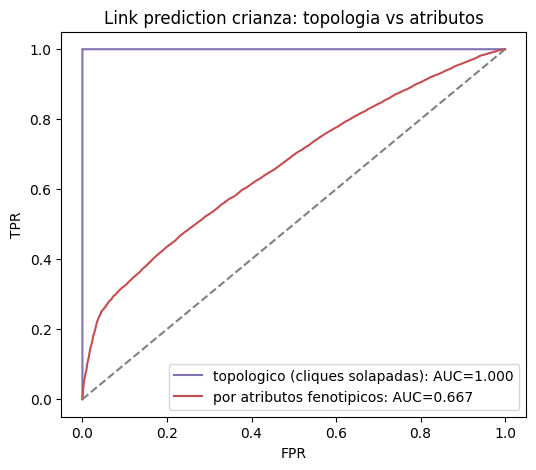

In [21]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import train_test_split

nodes = sorted(set(ed.a) | set(ed.b)); nl = np.array(nodes)
edge_set = {(min(a,b), max(a,b)) for a,b in zip(ed.a, ed.b)}
pos = np.array(list(edge_set))
sf = q("""MATCH (s:Species)<-[:IS_SPECIES]-(p:Pokemon {is_default:true})-[r:HAS_STAT]->(st:Stat)
RETURN s.id AS sid, st.identifier AS stat, r.base_stat AS v""").pivot_table(index="sid",columns="stat",values="v",fill_value=0)
sm = q("""MATCH (s:Species) OPTIONAL MATCH (s)<-[:IS_SPECIES]-(:Pokemon {is_default:true})-[:HAS_TYPE {slot:1}]->(t:Type)
RETURN s.id AS sid, s.generation_id AS gen, t.identifier AS ptype""").set_index("sid")
def rand_neg(k, rng):
    out=set()
    while len(out)<k:
        u,v=rng.choice(nl,2,replace=False); e=(int(min(u,v)),int(max(u,v)))
        if e not in edge_set: out.add(e)
    return np.array(list(out))
def topo(pairs, adj, logdeg):   # vecindario sobre adyacencia de train (sin fuga); log(grado) precomputado
    r=[]
    for u,v in pairs:
        nu,nv=adj[u],adj[v]; cm=nu&nv; cn=len(cm); un=len(nu)+len(nv)-cn
        r.append([cn, cn/un if un else 0, sum(logdeg[w] for w in cm), len(nu)*len(nv)])
    return np.array(r,dtype=float)
def attr(pairs):
    r=[]
    for u,v in pairs:
        d=list(np.abs(sf.loc[u].values-sf.loc[v].values))
        st=1.0 if (pd.notna(sm.loc[u,'ptype']) and sm.loc[u,'ptype']==sm.loc[v,'ptype']) else 0.0
        sg=1.0 if sm.loc[u,'gen']==sm.loc[v,'gen'] else 0.0
        r.append(d+[st,sg])
    return np.array(r,dtype=float)
def ev(seed):
    rng=np.random.default_rng(seed)
    ptr,pte=train_test_split(pos,test_size=0.2,random_state=seed)
    adj={n:set() for n in nodes}
    for a,b in ptr: a,b=int(a),int(b); adj[a].add(b); adj[b].add(a)
    logdeg={w:1.0/math.log(dd) for w in adj if (dd:=len(adj[w]))>1}
    neg=rand_neg(len(pos),rng); ntr,nte=train_test_split(neg,test_size=0.2,random_state=seed)
    ytr=np.r_[np.ones(len(ptr)),np.zeros(len(ntr))]; yte=np.r_[np.ones(len(pte)),np.zeros(len(nte))]
    o={}
    for nombre,fz in [("topo",lambda P: topo(P,adj,logdeg)),("attr",attr)]:
        m=RandomForestClassifier(300,random_state=seed,n_jobs=-1).fit(np.vstack([fz(ptr),fz(ntr)]),ytr)
        p=m.predict_proba(np.vstack([fz(pte),fz(nte)]))[:,1]
        o[nombre]=(roc_auc_score(yte,p),average_precision_score(yte,p),roc_curve(yte,p))
    return o
runs=[ev(k) for k in range(5)]   # 5 splits -> media+/-std; el AP esta sobre set balanceado 1:1 (base 0.5)
def ms(key,i): return np.mean([r[key][i] for r in runs]),np.std([r[key][i] for r in runs])
print(f"grafo crianza: {len(nodes)} especies, {len(pos)} pares compatibles")
print(f"2a) topologico (CN/Jaccard/AA/PA): AUC={ms('topo',0)[0]:.3f}+/-{ms('topo',0)[1]:.3f}  AP={ms('topo',1)[0]:.3f} (1:1, base 0.5)")
print(f"2b) por atributos fenotipicos:     AUC={ms('attr',0)[0]:.3f}+/-{ms('attr',0)[1]:.3f}  AP={ms('attr',1)[0]:.3f} (1:1, base 0.5)")
plt.figure(figsize=(6,5))
for nombre,l,c in [("topo","topologico (cliques solapadas)","#8172b3"),("attr","por atributos fenotipicos","#c44e52")]:
    fpr,tpr,_=runs[0][nombre][2]; plt.plot(fpr,tpr,color=c,label=f"{l}: AUC={ms(nombre,0)[0]:.3f}")
plt.plot([0,1],[0,1],'--',color='gray'); plt.legend(loc='lower right')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Link prediction crianza: topologia vs atributos"); plt.show()

## 5. Conclusiones

PokeAPI resulto un grafo de conocimiento genuino: cumple el criterio duro del enunciado (N-a-N
navegable, ciclos, recursion), todo verificado contra los datos, con del orden de 130 mil nodos
y 900 mil aristas. Los conteos exactos estan en la seccion 1.

El grafo de propiedades fue la eleccion correcta. `CAN_LEARN` carga propiedades en la arista y es
un multigrafo (el mismo par pokemon-move se repite por version y metodo), algo que en RDF puro
obligaria a reificar. Las consultas P1-P9 se apoyan en esa estructura: ciclos del type chart,
paths evolutivos, comunidades y centralidad de crianza, proyecciones N-a-N de movesets.

Del ML salieron dos lecturas honestas. El grafo de crianza es una union de cliques solapadas (una
por egg group), asi que predecir enlaces por topologia da AUC ~1.0, pero eso describe el grafo, no
al modelo; preguntar lo no trivial, si dos especies pueden cruzarse mirando solo su fenotipo, baja
a AUC ~0.67. Y la clasificacion de tipo llega a ~0.82, pero buena parte de esa señal es el movepool
(efecto STAB): con solo las stats base cae a ~0.20. Las dos cifras altas se caen apenas se controla
por lo que de verdad las explica, asi que conviene leer la letra chica antes que el numero pelado.


In [22]:
driver.close()
print("fin del reporte")

fin del reporte
